## Setup

In [ ]:
import os

# =====================================================
# PROJECT ROOT
# =====================================================

PROJECT_ROOT = os.path.abspath(
    os.path.join(os.getcwd(), "..")
)

# =====================================================
# DATA PATH
# =====================================================

BASE_DIR = os.path.join(
    PROJECT_ROOT,
    "data",
    "raw"
)

os.makedirs(BASE_DIR, exist_ok=True)

print(f"Analyzing directory: {BASE_DIR}")

# =====================================================
# FIND ALL EXPERIMENTS
# =====================================================

experiment_folders = []

for entry in os.scandir(BASE_DIR):

    if entry.is_dir():

        experiment_folders.append(entry.path)

# =====================================================
# SORT FOR CONSISTENT ORDER
# =====================================================

experiment_folders = sorted(experiment_folders)

# =====================================================
# DEBUG
# =====================================================

print(f"Total experiments: {len(experiment_folders)}")

for exp in experiment_folders:
    print(os.path.basename(exp))

Analyzing directory: /home/rafael/programacao/comp-sys-perf-analysis/data/raw
Total experiments: 10
N1_tupi_none_long_r1_780636
N1_tupi_none_short_r1_780637
N2_poti_PP_long_r1_780630
N2_poti_PP_short_r1_780628
N2_poti_TP_long_r1_780629
N2_poti_TP_short_r1_780627
N4_poti_PP_long_r1_780638
N4_poti_PP_short_r1_780634
N4_poti_TP_long_r1_780632
N4_poti_TP_short_r1_780631


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import os

def find_telemetry_files(experiment_path):
    telemetry_files = []

    for root, _, files in os.walk(experiment_path):
        if 'telemetry.csv' in files:
            telemetry_files.append(os.path.join(root, 'telemetry.csv'))

    return telemetry_files

def plot_gpu_utilization_for_experiment(experiment_path):
    experiment_name = os.path.basename(experiment_path)

    telemetry_files = find_telemetry_files(experiment_path)

    if not telemetry_files:
        print(f"No telemetry found for {experiment_name}")
        return

    plt.figure(figsize=(15, 6))

    for file_path in telemetry_files:
        try:
            df = pd.read_csv(file_path)

            # Clean column names (IMPORTANT)
            df.columns = [c.strip() for c in df.columns]

            if 'timestamp' not in df.columns or 'utilization.gpu [%]' not in df.columns:
                continue

            df['timestamp'] = pd.to_datetime(df['timestamp'])
            df = df.sort_values('timestamp')

            # Label by node (folder name: poti1, poti5, tupi6, etc.)
            node_name = os.path.basename(os.path.dirname(file_path))

            plt.plot(
                df['timestamp'],
                df['utilization.gpu [%]'],
                label=node_name
            )

        except Exception as e:
            print(f"Error reading {file_path}: {e}")

    plt.title(f'GPU Utilization - {experiment_name}')
    plt.xlabel('Time')
    plt.ylabel('GPU Utilization (%)')
    plt.legend(title='Node')
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

In [8]:
def format_node_name(node):
    # poti1 → POTI-1
    # tupi6 → TUPI-6
    import re
    match = re.match(r'([a-zA-Z]+)(\d+)', node)
    if match:
        return f"{match.group(1).upper()}-{match.group(2)}"
    return node.upper()

In [9]:
def plot_gpu_memory_usage(experiment_path):
    experiment_name = os.path.basename(experiment_path)
    telemetry_files = find_telemetry_files(experiment_path)

    plt.figure(figsize=(15, 6))

    for file_path in telemetry_files:
        df = pd.read_csv(file_path)
        df.columns = [c.strip() for c in df.columns]

        if 'timestamp' not in df.columns or 'memory.used [MiB]' not in df.columns:
            continue

        df['timestamp'] = pd.to_datetime(df['timestamp'])
        df = df.sort_values('timestamp')

        node_raw = os.path.basename(os.path.dirname(file_path))
        node_name = format_node_name(node_raw)
        plt.plot(
            df['timestamp'],
            df['memory.used [MiB]'],
            label=node_name
        )

    plt.title(f'GPU Memory Usage - {experiment_name}')
    plt.xlabel('Time')
    plt.ylabel('Memory Used (MiB)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

In [10]:
def plot_gpu_power(experiment_path):
    experiment_name = os.path.basename(experiment_path)
    telemetry_files = find_telemetry_files(experiment_path)

    plt.figure(figsize=(15, 6))

    for file_path in telemetry_files:
        df = pd.read_csv(file_path)
        df.columns = [c.strip() for c in df.columns]

        if 'timestamp' not in df.columns or 'power.draw [W]' not in df.columns:
            continue

        df['timestamp'] = pd.to_datetime(df['timestamp'])
        df = df.sort_values('timestamp')

        node_name = os.path.basename(os.path.dirname(file_path))

        plt.plot(
            df['timestamp'],
            df['power.draw [W]'],
            label=node_name
        )

    plt.title(f'GPU Power Draw - {experiment_name}')
    plt.xlabel('Time')
    plt.ylabel('Power (W)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

In [11]:
def plot_gpu_temperature(experiment_path):
    experiment_name = os.path.basename(experiment_path)
    telemetry_files = find_telemetry_files(experiment_path)

    if not telemetry_files:
        print(f"No telemetry found for {experiment_name}")
        return

    plt.figure(figsize=(15, 6))

    for file_path in telemetry_files:
        try:
            df = pd.read_csv(file_path)

            # Clean column names
            df.columns = [c.strip() for c in df.columns]

            if 'timestamp' not in df.columns:
                continue

            # Handle possible temperature column variations
            temp_col = None
            for candidate in ['temperature.gpu', 'temperature.gpu [C]', 'temperature.gpu [°C]']:
                if candidate in df.columns:
                    temp_col = candidate
                    break

            if temp_col is None:
                continue

            df['timestamp'] = pd.to_datetime(df['timestamp'])
            df = df.sort_values('timestamp')

            node_name = os.path.basename(os.path.dirname(file_path))

            plt.plot(
                df['timestamp'],
                df[temp_col],
                label=node_name
            )

        except Exception as e:
            print(f"Error reading {file_path}: {e}")

    plt.title(f'GPU Temperature - {experiment_name}')
    plt.xlabel('Time')
    plt.ylabel('Temperature (°C)')
    plt.legend(title='Node')
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

In [12]:
def format_experiment_name(name):
    # Tratamento para evitar o erro de 'split' em valores nulos ou numéricos
    if not isinstance(name, str) or pd.isna(name):
        return "Unknown Experiment"

    parts = name.split('_')
    
    # Se o nome não tiver o formato esperado (partes separadas por _), retorna o original
    if len(parts) < 4:
        return name

    try:
        # Exemplo: N1_poti_none_short_r1_778989
        n_nodes = parts[0]
        system = parts[1].upper()
        strategy = parts[2]
        length = parts[3]

        # Tradução amigável
        node_text = f"{n_nodes[1:]} Node" if n_nodes == "N1" else f"{n_nodes[1:]} Nodes"
        
        strat_map = {"none": "No Comm", "PP": "Pipeline Parallel", "TP": "Tensor Parallel"}
        strategy_text = strat_map.get(strategy, strategy)
        
        len_text = "Short" if length == "short" else "Long"
        
        return f"{node_text} {system}\n{strategy_text} ({len_text})"
    except Exception:
        return name

In [13]:
def sort_experiments(exp_path):
    name = os.path.basename(exp_path).lower()

    # ===== PARALLELISM TYPE =====
    if 'infer' in name or 'n1' in name or 'none' in name:
        parallel_rank = 0   # Single GPU
    elif 'tp' in name:
        parallel_rank = 1   # Tensor Parallel
    elif 'pp' in name:
        parallel_rank = 2   # Pipeline Parallel
    else:
        parallel_rank = 3   # Unknown / fallback

    # ===== INPUT SIZE =====
    if 'short' in name:
        size_rank = 0
    elif 'long' in name:
        size_rank = 1
    else:
        size_rank = 2

    # ===== MACHINE COUNT (optional refinement) =====
    if 'n1' in name:
        machine_rank = 0
    elif 'n2' in name:
        machine_rank = 1
    else:
        machine_rank = 2

    return (parallel_rank, size_rank, machine_rank, name)

Saved: /home/rafael/programacao/comp-sys-perf-analysis/data/figures/03_telemetry/gpu-overview-N1-tupi-none-short-r1-780637.png


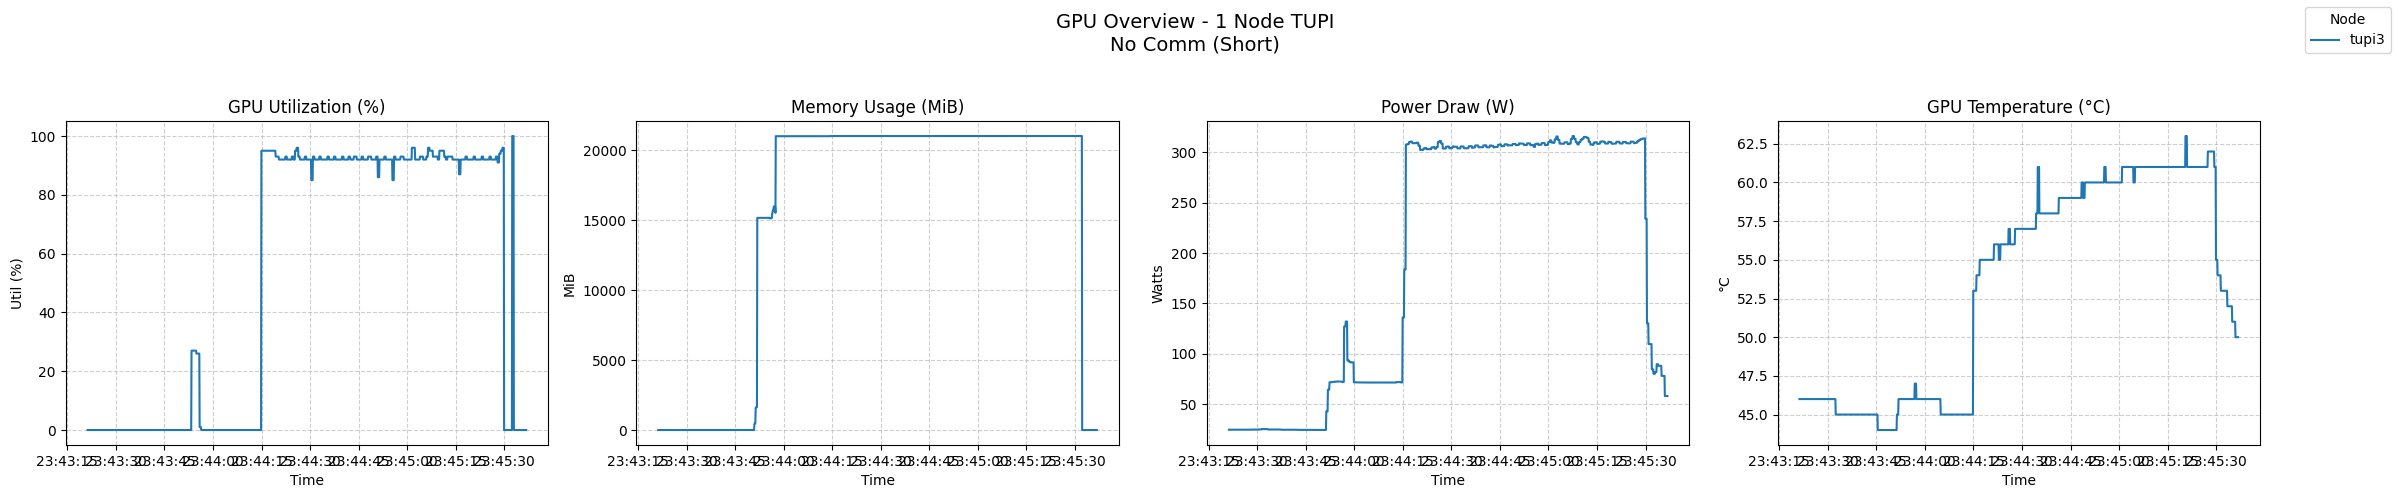

Saved: /home/rafael/programacao/comp-sys-perf-analysis/data/figures/03_telemetry/gpu-overview-N1-tupi-none-long-r1-780636.png


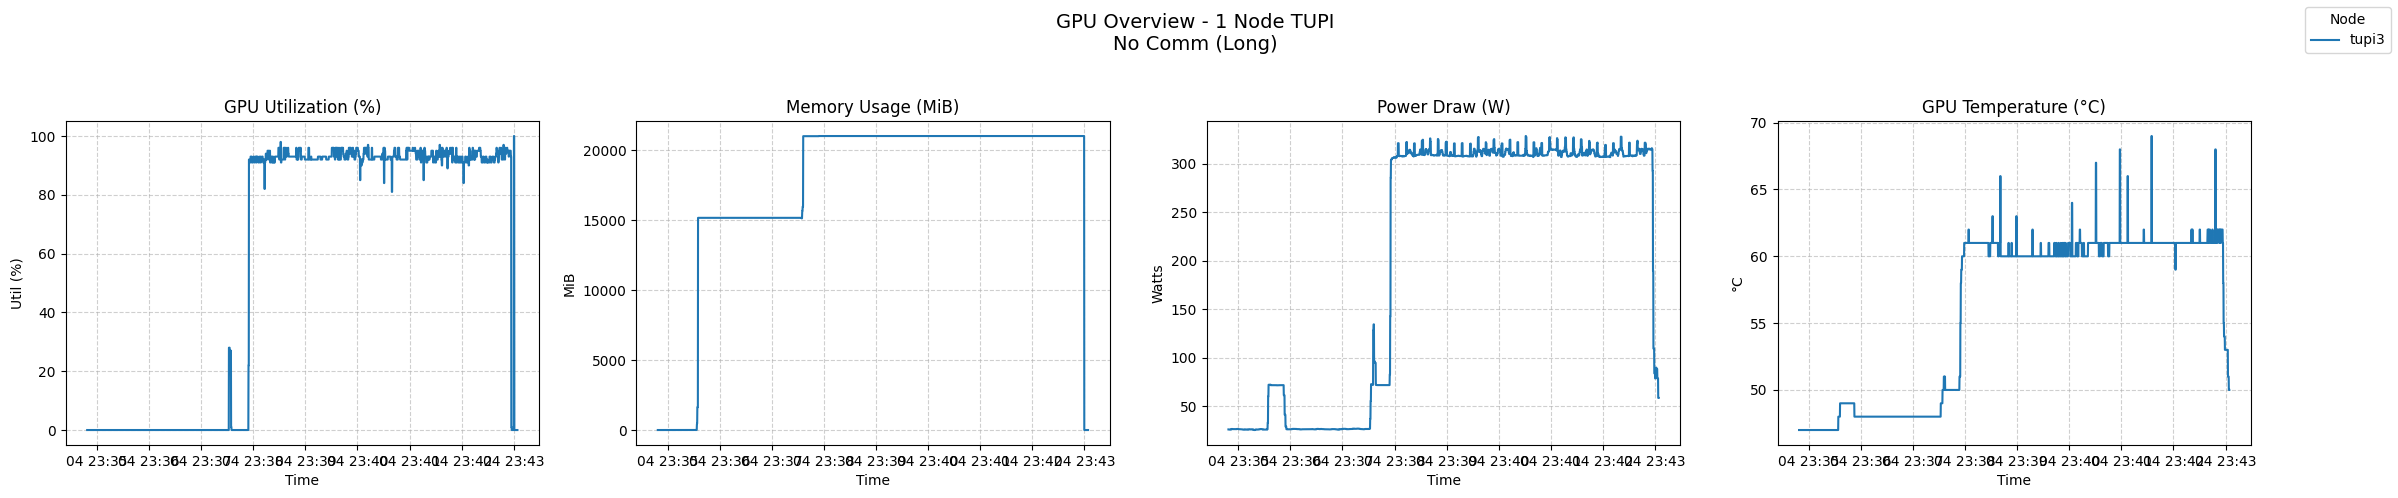

Saved: /home/rafael/programacao/comp-sys-perf-analysis/data/figures/03_telemetry/gpu-overview-N2-poti-TP-short-r1-780627.png


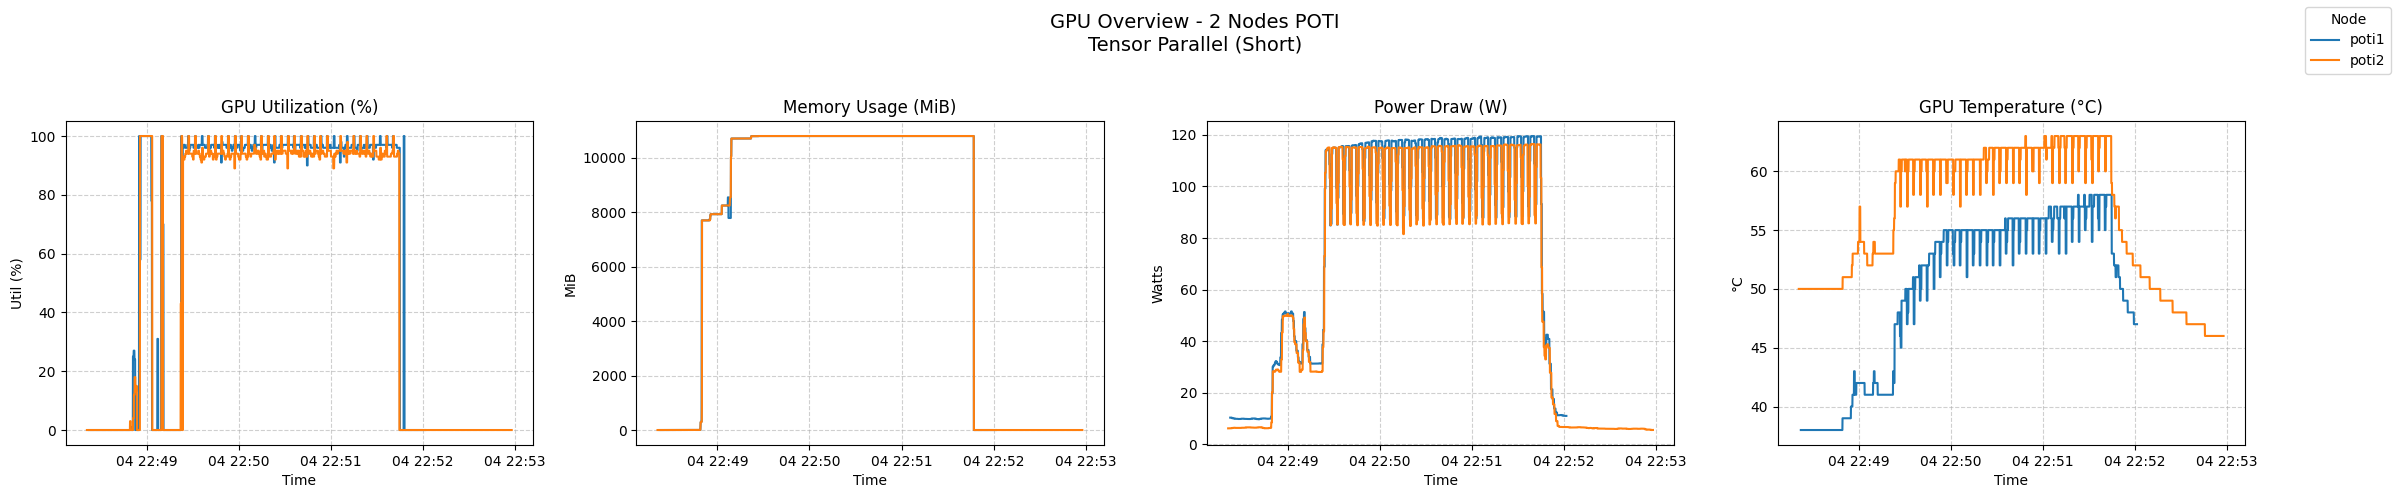

Saved: /home/rafael/programacao/comp-sys-perf-analysis/data/figures/03_telemetry/gpu-overview-N4-poti-TP-short-r1-780631.png


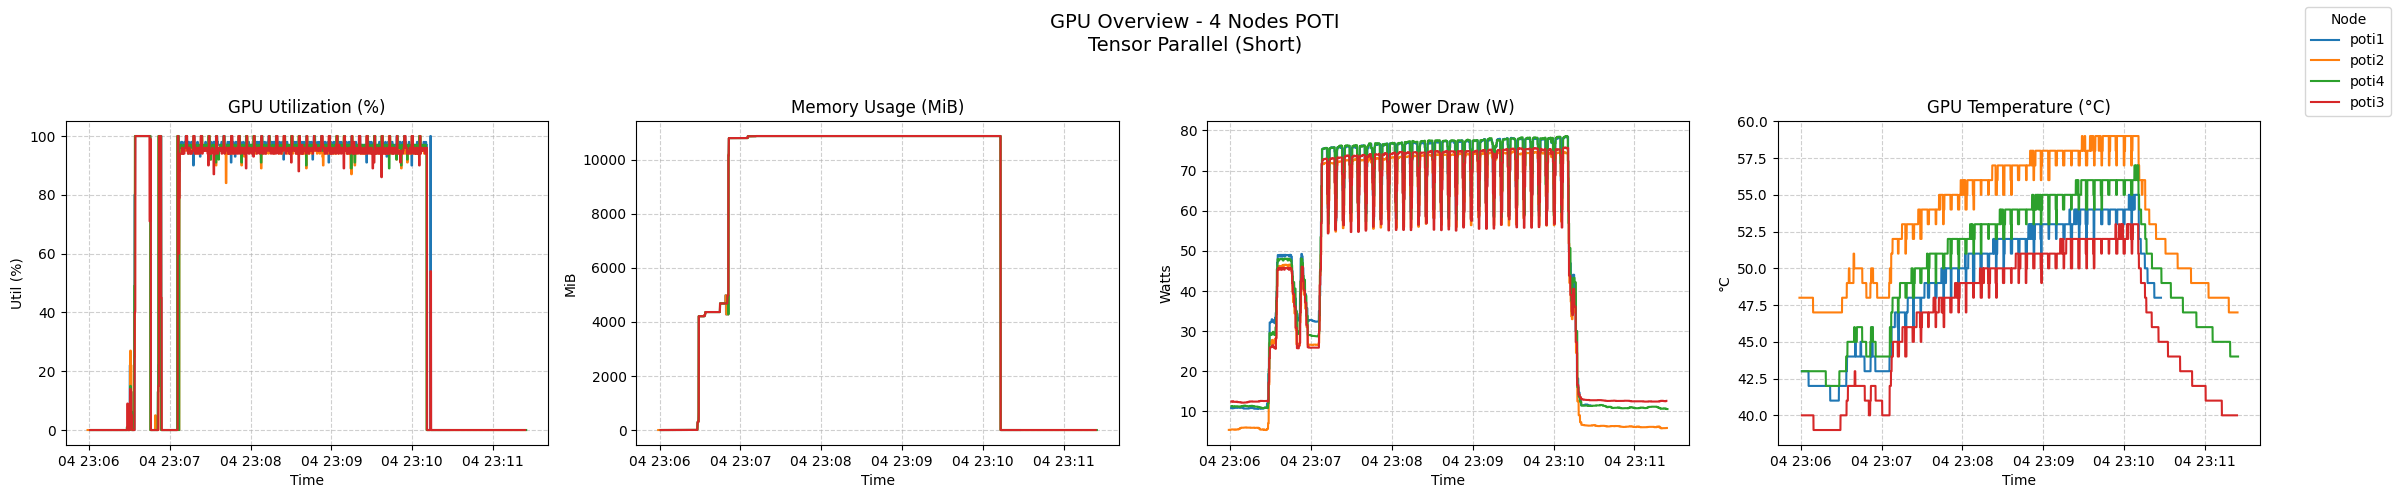

Saved: /home/rafael/programacao/comp-sys-perf-analysis/data/figures/03_telemetry/gpu-overview-N2-poti-TP-long-r1-780629.png


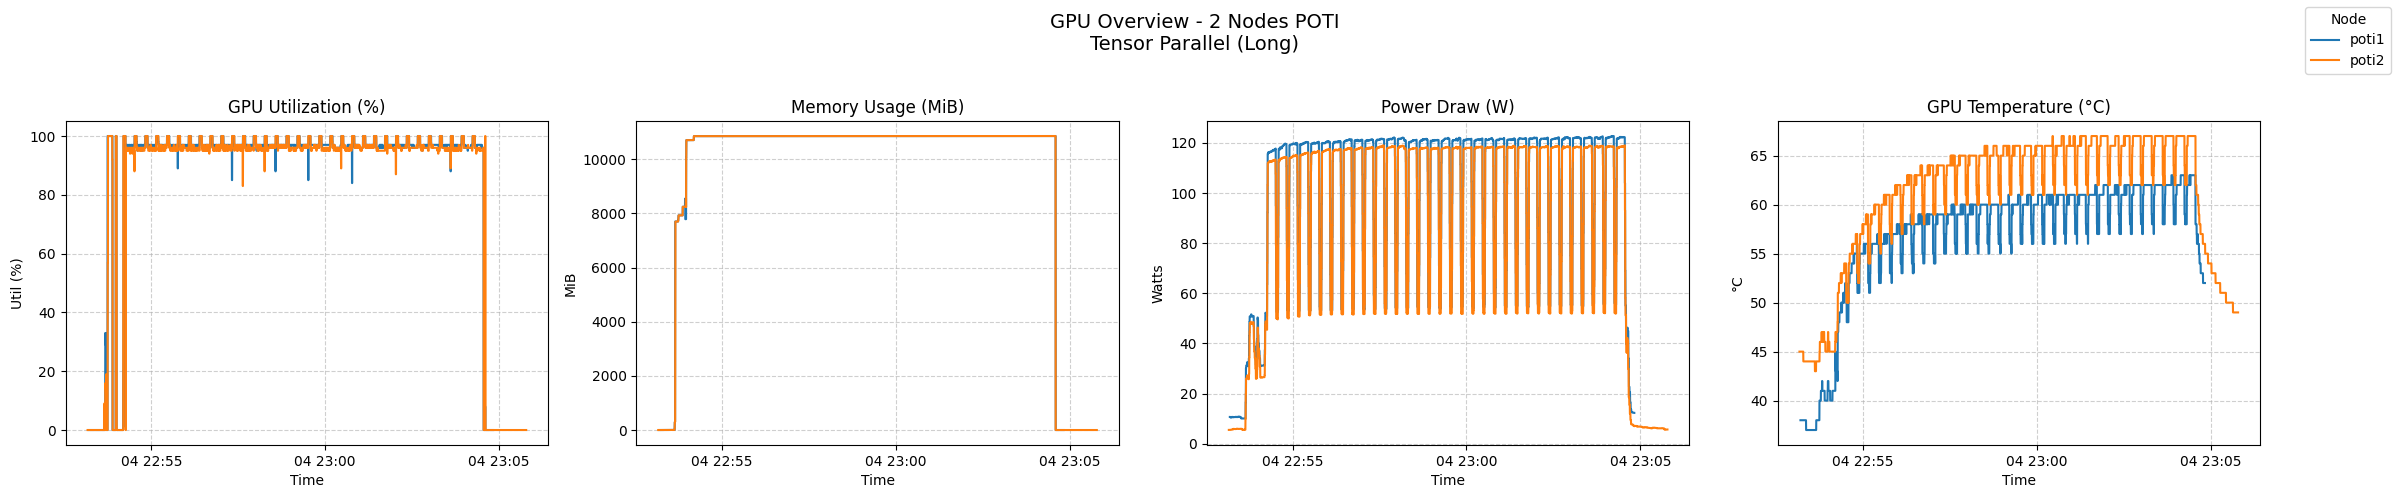

Saved: /home/rafael/programacao/comp-sys-perf-analysis/data/figures/03_telemetry/gpu-overview-N4-poti-TP-long-r1-780632.png


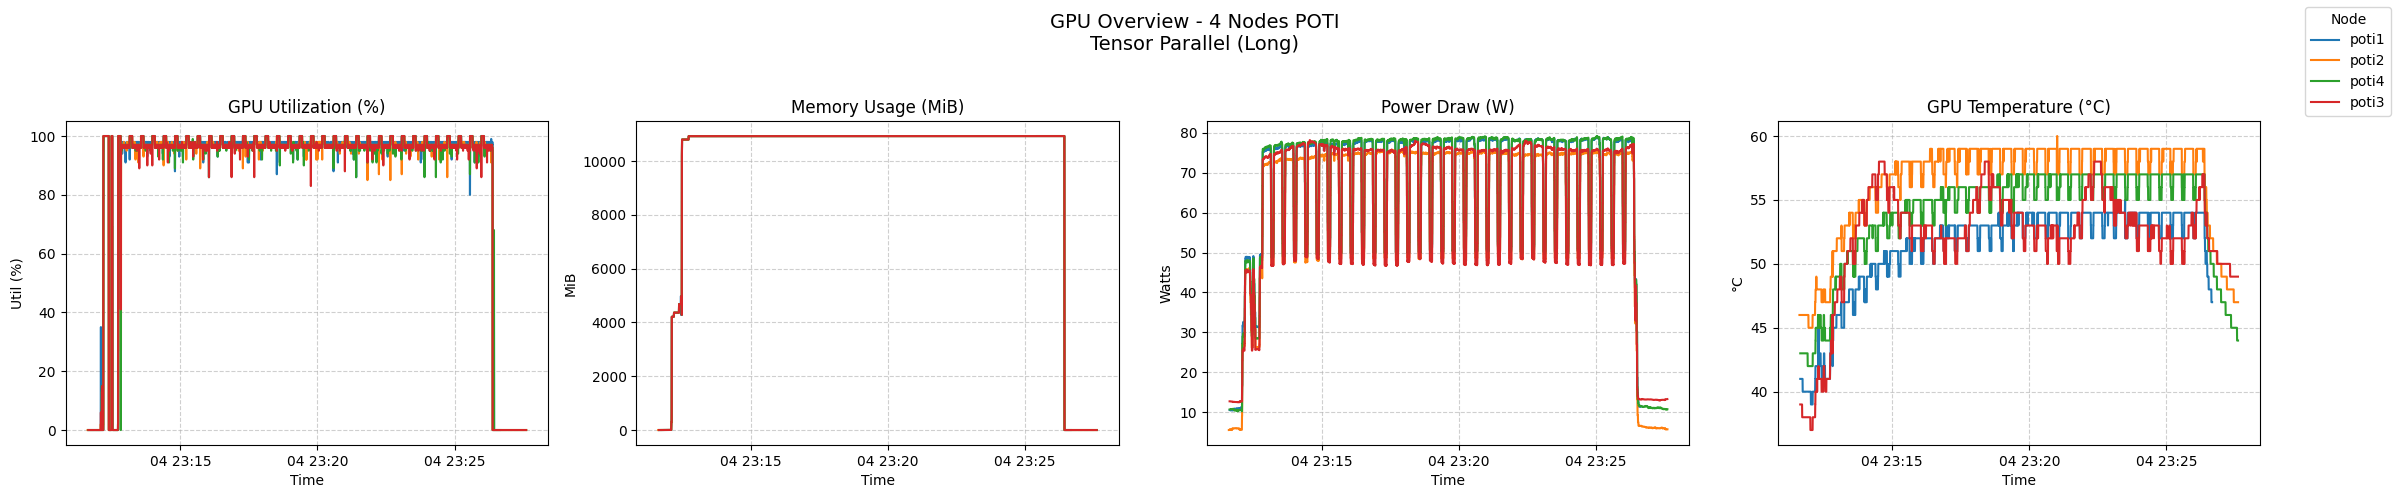

Saved: /home/rafael/programacao/comp-sys-perf-analysis/data/figures/03_telemetry/gpu-overview-N2-poti-PP-short-r1-780628.png


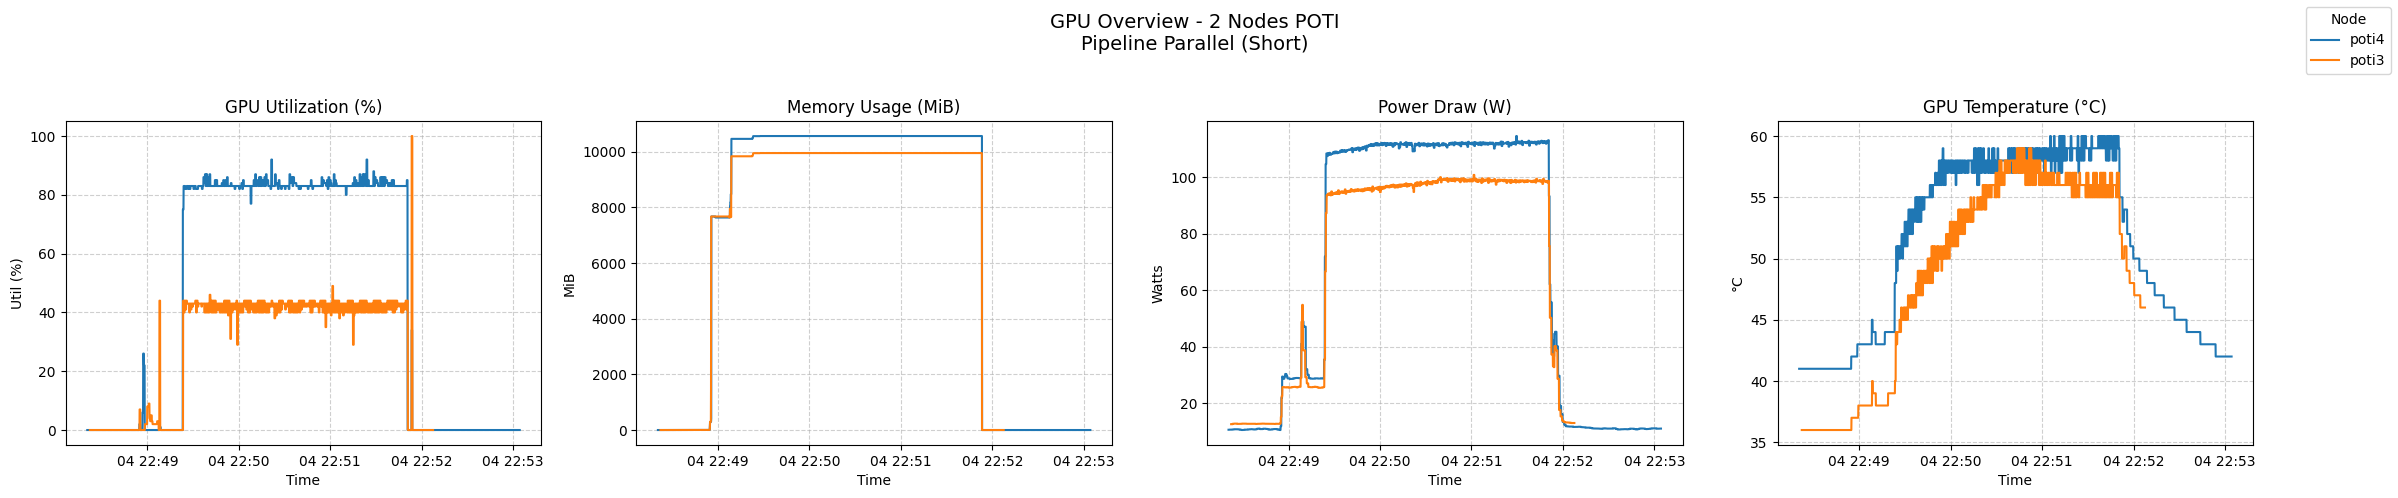

Saved: /home/rafael/programacao/comp-sys-perf-analysis/data/figures/03_telemetry/gpu-overview-N4-poti-PP-short-r1-780634.png


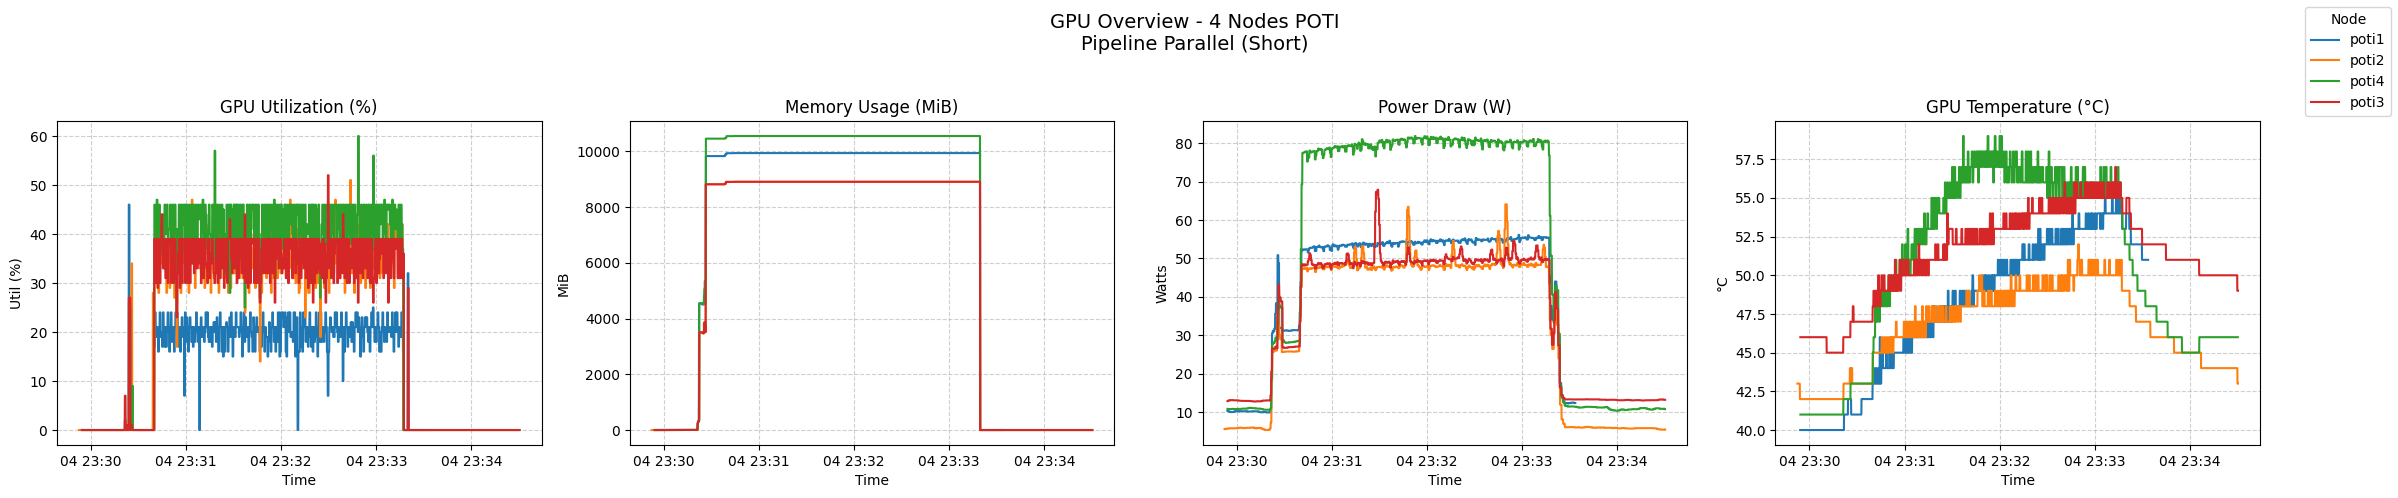

Saved: /home/rafael/programacao/comp-sys-perf-analysis/data/figures/03_telemetry/gpu-overview-N2-poti-PP-long-r1-780630.png


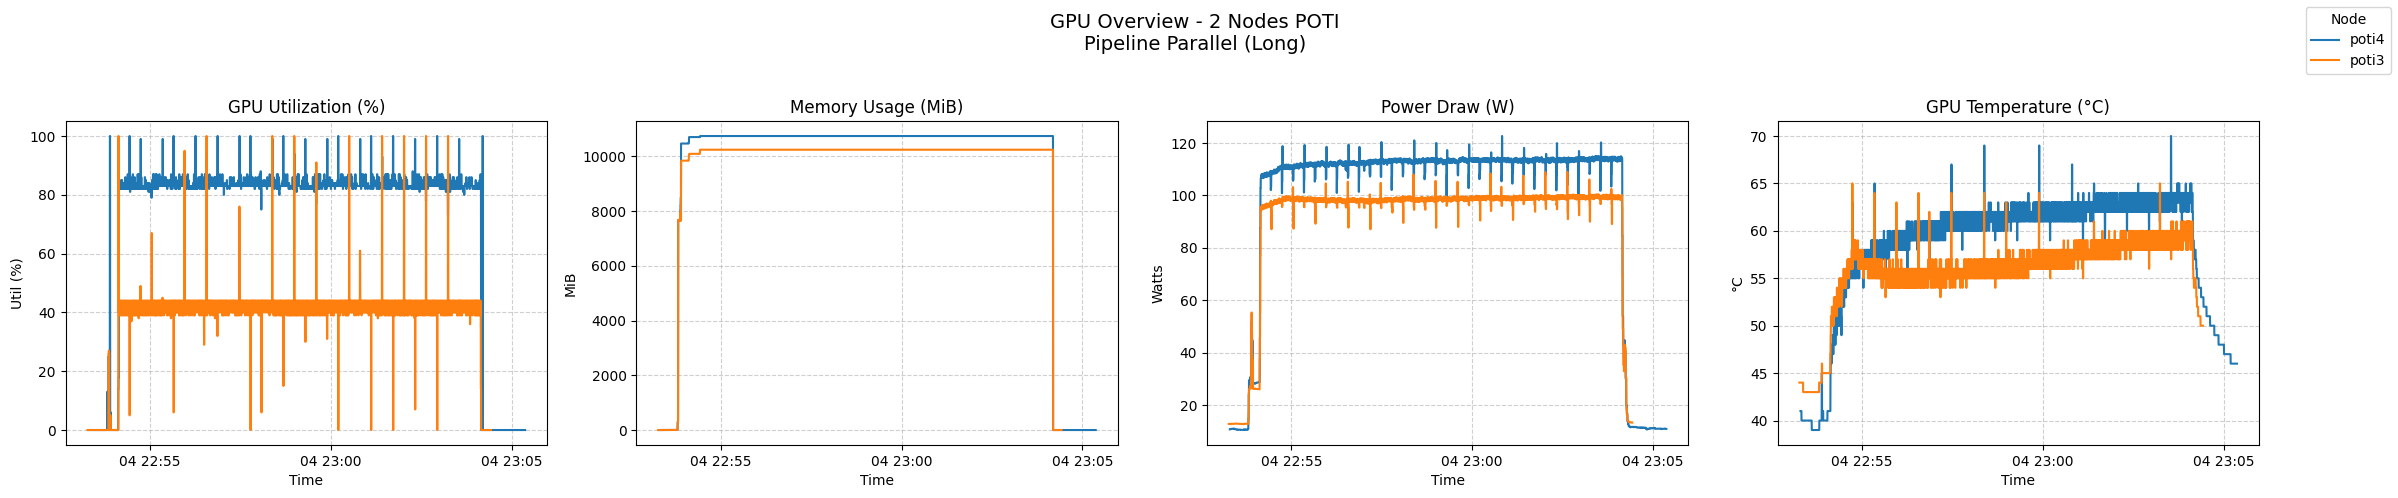

Saved: /home/rafael/programacao/comp-sys-perf-analysis/data/figures/03_telemetry/gpu-overview-N4-poti-PP-long-r1-780638.png


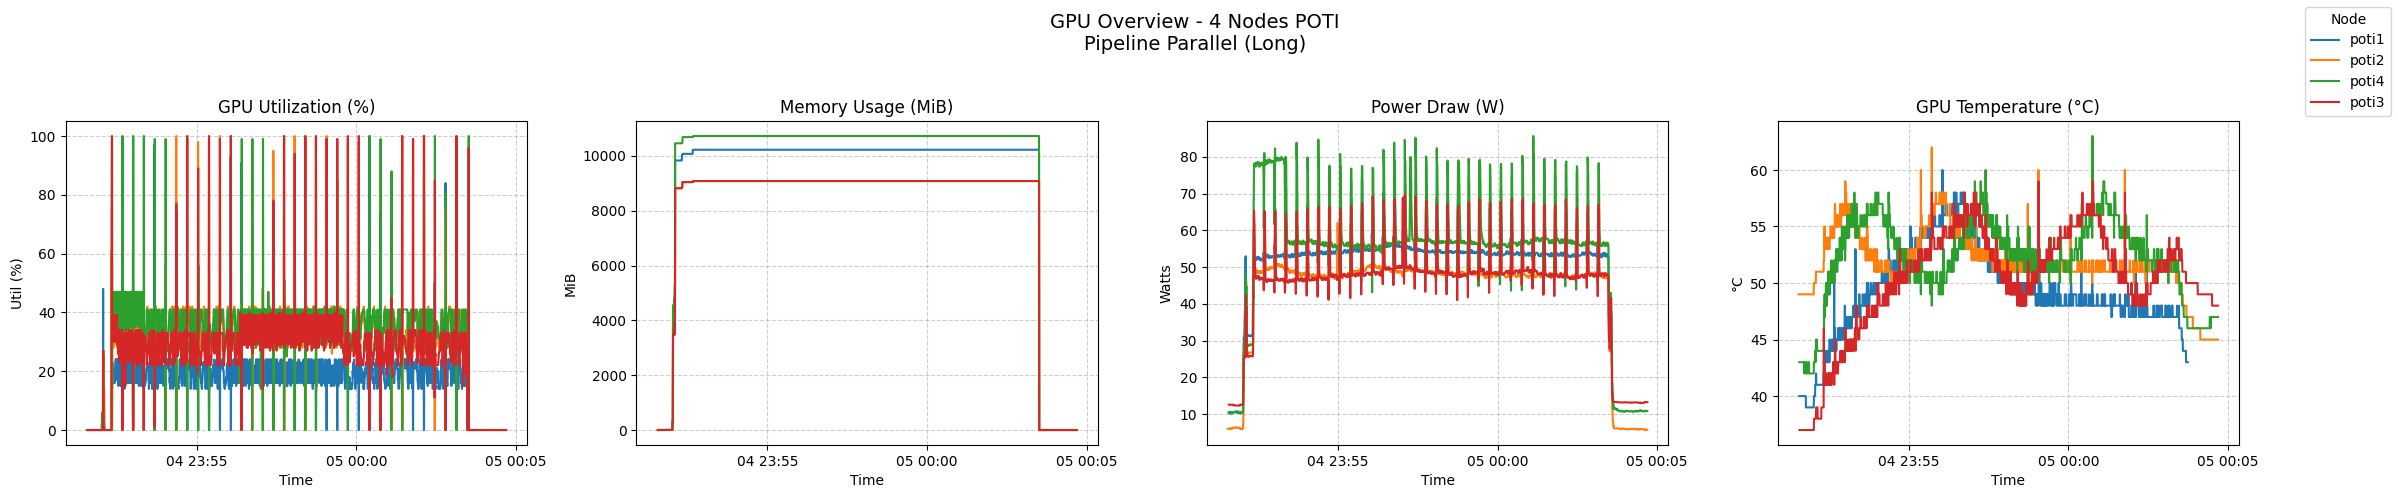

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import os

from pathlib import Path
output_dir = Path("../data/figures/03_telemetry")
output_dir.mkdir(parents=True, exist_ok=True)

def find_telemetry_files(experiment_path):
    telemetry_files = []

    for root, _, files in os.walk(experiment_path):
        if 'telemetry.csv' in files:
            telemetry_files.append(os.path.join(root, 'telemetry.csv'))

    return telemetry_files


def plot_gpu_overview(experiment_path):
    raw_name = os.path.basename(experiment_path)
    experiment_name = format_experiment_name(raw_name)

    telemetry_files = find_telemetry_files(experiment_path)

    if not telemetry_files:
        print(f"No telemetry found for {experiment_name}")
        return

    fig, axes = plt.subplots(1, 4, figsize=(24, 5), sharex=True)
    ax_util, ax_mem, ax_power, ax_temp = axes

    for file_path in telemetry_files:
        try:
            df = pd.read_csv(file_path)
            df.columns = [c.strip() for c in df.columns]

            if 'timestamp' not in df.columns:
                continue

            df['timestamp'] = pd.to_datetime(df['timestamp'])
            df = df.sort_values('timestamp')

            node_name = os.path.basename(os.path.dirname(file_path))

            if 'utilization.gpu [%]' in df.columns:
                ax_util.plot(df['timestamp'], df['utilization.gpu [%]'], label=node_name)

            if 'memory.used [MiB]' in df.columns:
                ax_mem.plot(df['timestamp'], df['memory.used [MiB]'], label=node_name)

            if 'power.draw [W]' in df.columns:
                ax_power.plot(df['timestamp'], df['power.draw [W]'], label=node_name)

            if 'temperature.gpu' in df.columns:
                ax_temp.plot(df['timestamp'], df['temperature.gpu'], label=node_name)

        except Exception as e:
            print(f"Error reading {file_path}: {e}")

    ax_util.set_title('GPU Utilization (%)')
    ax_mem.set_title('Memory Usage (MiB)')
    ax_power.set_title('Power Draw (W)')
    ax_temp.set_title('GPU Temperature (°C)')

    ax_util.set_ylabel('Util (%)')
    ax_mem.set_ylabel('MiB')
    ax_power.set_ylabel('Watts')
    ax_temp.set_ylabel('°C')

    for ax in axes:
        ax.set_xlabel('Time')
        ax.grid(True, linestyle='--', alpha=0.6)

    handles, labels = ax_util.get_legend_handles_labels()
    fig.legend(handles, labels, title='Node', loc='upper right')

    fig.suptitle(f'GPU Overview - {experiment_name}', fontsize=14)
    plt.tight_layout(rect=[0, 0, 0.95, 0.95])

    # =====================================================
    # SAVE
    # =====================================================
    filename = raw_name.replace('_', '-')
    filepath = output_dir / f"gpu-overview-{filename}.png"
    plt.savefig(filepath, dpi=150, bbox_inches='tight')
    print(f"Saved: {filepath.resolve()}")

    plt.show()


# ===== LOOP =====
experiment_folders = sorted(experiment_folders, key=sort_experiments)

for exp_path in experiment_folders:
    plot_gpu_overview(exp_path)

Pipeline parallelism shows a clear imbalance in GPU utilization: one GPU operates around 40–50% while the other remains close to 90–100%. This behavior is expected from the pipeline execution model. In pipeline parallelism, different stages of the model are assigned to different GPUs, and tokens must flow sequentially through these stages. As a result, some GPUs spend part of their time idle, waiting for data from previous stages (pipeline “bubbles”). This underutilization reduces overall efficiency and increases inter-token latency.

In contrast, tensor parallelism distributes the computation of each layer across multiple GPUs simultaneously. Both GPUs work on the same operation at the same time, leading to consistently high utilization (close to 100%) on all devices. This more balanced workload reduces idle time and generally results in lower inter-token latency compared to pipeline parallelism.

When running on a single machine without communication, the GPU also reaches near 100% utilization. In this case, there is no inter-device synchronization or data transfer overhead, which explains why inter-token latency and related time metrics are significantly lower—often close to half of the multi-GPU setups. However, this comes at the cost of higher per-device resource usage, including memory and power, since all computations are concentrated on a single GPU.

Overall, the observed results are consistent with the expected trade-offs: pipeline parallelism suffers from idle stages and higher latency, tensor parallelism achieves better balance but still incurs communication overhead, and single-GPU execution avoids communication entirely, yielding the lowest latency.